<a href="https://colab.research.google.com/github/zombimann/Mathematical-video-animations-and-visualization/blob/main/Sierpinski_Triangle_Fractal_Infinite_Zoom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Fractal Infinity: The Sierpinski Zoom

This notebook generates a high-definition animation of the **Sierpinski Triangle** being constructed through the **Chaos Game** algorithm. It features a cinematic recursive zoom that dives into the fractal levels as they emerge from randomness.

##
e0f How it Works
1. **The Chaos Game**: We start with three vertices of an equilateral triangle.
2. **The Rule**: Starting from a random point, we repeatedly pick one vertex at random and move half the distance toward it, plotting a point at each step.
3. **Emergence**: Despite the randomness of vertex selection, the global structure of the Sierpinski Triangle emerges with infinite detail.

## Features
- **Cinematic Zoom**: Smooth camera interpolation zooming into the top-most recursion levels.
- **FFMpeg Rendering**: Generates a high-quality `.mp4` file suitable for sharing.
- **Neon Aesthetic**: Cosmic black background with glowing cyan, magenta, and yellow points.

##  Requirements
- `ffmpeg`: For video encoding.
- `matplotlib`: For plotting and animation frames.
- `numpy`: For the chaos game math logic.

---

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
🎬 Rendering recursive zoom video...
✅ DONE! Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

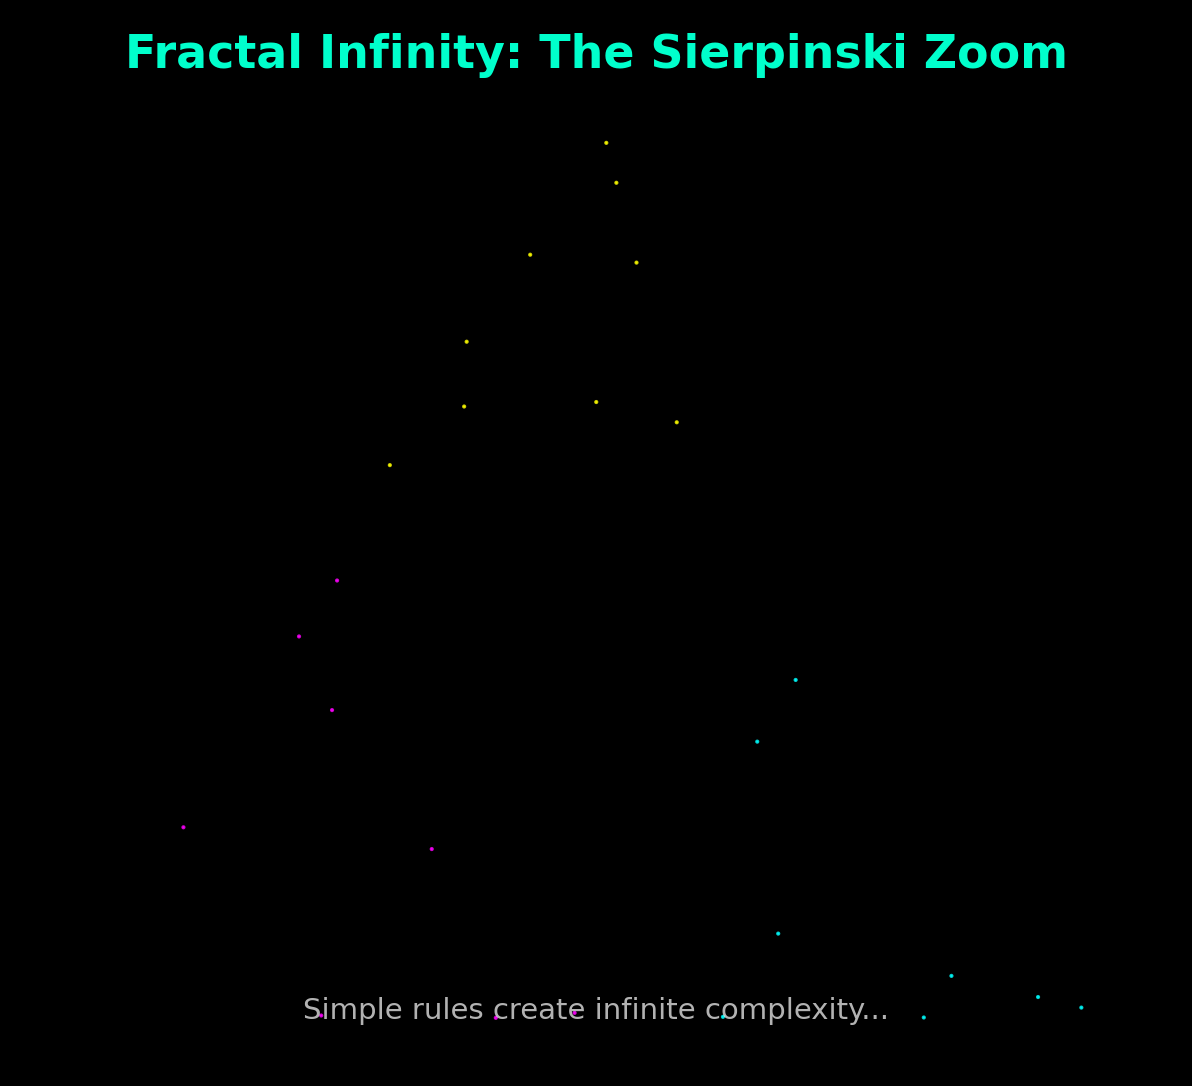

In [3]:
!apt-get update -qq && apt-get install -y ffmpeg -qq

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

# ====================== SETTINGS ======================
N_POINTS = 30000
FPS = 30
DURATION = 40  # Seconds
TOTAL_FRAMES = FPS * DURATION
ZOOM_STAGES = 5
POINTS_PER_FRAME = N_POINTS // TOTAL_FRAMES

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

# Chaos Game Setup
vertices = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3)/2]])
colors = ['#ff00ff', '#00ffff', '#ffff00']

np.random.seed(42)
points = []
current = np.array([0.5, 0.3])
for _ in range(N_POINTS):
    v_idx = np.random.randint(3)
    current = 0.5 * (current + vertices[v_idx])
    points.append([current[0], current[1], v_idx])
points = np.array(points)

# Plotting elements
scatter = ax.scatter([], [], s=1, alpha=0.8, edgecolors='none')
title = ax.text(0.5, 0.95, "Fractal Infinity: The Sierpinski Zoom",
                fontsize=22, ha='center', color='#00ffcc', fontweight='bold', transform=ax.transAxes)
subtitle = ax.text(0.5, 0.05, "", fontsize=14, ha='center', color='white', alpha=0.7, transform=ax.transAxes)

ax.axis('off')
ax.set_aspect('equal')

# Zoom Logic: Calculate viewport for each stage
# We zoom towards the top vertex: vertices[2] = [0.5, sqrt(3)/2]
viewports = []
curr_min_x, curr_max_x = -0.05, 1.05
curr_min_y, curr_max_y = -0.05, 0.95

for i in range(ZOOM_STAGES + 1):
    viewports.append((curr_min_x, curr_max_x, curr_min_y, curr_max_y))
    # Calculate next zoom bounds focusing on the top half
    center_x = 0.5
    top_y = np.sqrt(3)/2
    curr_min_x = curr_min_x + (center_x - curr_min_x) * 0.5
    curr_max_x = curr_max_x - (curr_max_x - center_x) * 0.5
    curr_min_y = curr_min_y + (top_y - curr_min_y) * 0.5
    # curr_max_y stays near the top

def animate(frame):
    # 1. Update Points
    n = min((frame + 1) * POINTS_PER_FRAME, N_POINTS)
    scatter.set_offsets(points[:n, :2])
    scatter.set_color([colors[int(c)] for c in points[:n, 2]])

    # 2. Dynamic Zooming
    # Determine which stage we are in based on frame progress
    progress = frame / TOTAL_FRAMES
    stage_float = progress * ZOOM_STAGES
    idx = int(stage_float)
    t = stage_float - idx # interpolation factor

    if idx < ZOOM_STAGES:
        v1 = viewports[idx]
        v2 = viewports[idx+1]
        # Linear interpolation for smooth camera move
        xmin = v1[0] + (v2[0] - v1[0]) * t
        xmax = v1[1] + (v2[1] - v1[1]) * t
        ymin = v1[2] + (v2[2] - v1[2]) * t
        ymax = v1[3] + (v2[3] - v1[3]) * t
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

    # 3. Dynamic Subtitles
    if frame < 100:
        subtitle.set_text("Simple rules create infinite complexity...")
    elif idx > 0:
        subtitle.set_text(f"Zooming into Level {idx} Recursion...")

    return scatter, title, subtitle

ani = FuncAnimation(fig, animate, frames=TOTAL_FRAMES, interval=1000/FPS, blit=False)

print(" Rendering recursive zoom video...")
writer = FFMpegWriter(fps=FPS, bitrate=5000)
ani.save("sierpinski_zoom.mp4", writer=writer, dpi=150)

print(" DONE! Downloading...")
files.download("sierpinski_zoom.mp4")

from IPython.display import HTML
HTML(ani.to_html5_video())
